In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Load data

In [ ]:
file_path = "fda_adverse_events_2015_2026_CLEAN.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kanchana1990/fda-drug-adverse-event-reports-2015-to-2026-faers",
    file_path,
)

df.head()

/tmp/ipykernel_16371/1524297955.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 178M/178M [00:05<00:00, 33.7MB/s]


,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


#EDA

In [ ]:
df.shape

(528000, 30)

In [ ]:
unique_countries = df['country'].unique()
print("Unique countries:", unique_countries)
print("Total unique countries:", len(unique_countries))

Unique countries: ['US' 'BR' 'GB' 'SE' 'AU' 'Unknown' 'IT' 'JP' 'DE' 'NZ' 'CA' 'PT' 'CN'
 'FR' 'ES' 'KR' 'SG' 'TH' 'NL' 'VE' 'CH' 'TR' 'GR' 'IL' 'BY' 'BE' 'EG'
 'AT' 'CO' 'IN' 'HU' 'DK' 'AR' 'RU' 'IE' 'SK' 'MX' 'HK' 'MW' 'ZA' 'BG'
 'CL' 'RS' 'PL' 'SI' 'CZ' 'LT' 'TW' 'NO' 'PH' 'DZ' 'FI' 'EE' 'LU' 'PR'
 'ML' 'SA' 'GN' 'PY' 'EC' 'GT' 'MY' 'HR' 'PE' 'LB' 'PK' 'RO' 'UA' 'DM'
 'TN' 'CY' 'IS' 'IR' 'LK' 'BW' 'KP' 'BN' 'ID' 'AE' 'CI' 'QA' 'UY' 'KE'
 'DO' 'UG' 'TZ' 'CR' 'BS' 'JO' 'BO' 'AL' 'HT' 'VN' 'KW' 'ZW' 'PA' 'MD'
 'AD' 'GH' 'MK' 'MN' 'BH' 'CD' 'KZ' 'NG' 'BD' 'KH' 'CM' 'ET' 'MA' 'IQ'
 'SN' 'LS' 'OM' 'BA' 'ME' 'BB' 'GD' 'MZ' 'LV' 'HN' 'NI' 'SV' 'NP' 'GE'
 'AM' 'BF' 'KY' 'MM' 'KG' 'SY' 'FO' 'MT' 'AF' 'TT' 'MU' 'JM' 'TD' 'MC'
 'GI' 'NC' 'FJ' 'TJ' 'UZ' 'SD' 'RE' 'VI' 'SB' 'PG' 'LC' 'SR' 'SC' 'RW'
 'CU' 'AZ' 'ER' 'EU' 'UM' 'AO' 'YE' 'PF' 'TO']
Total unique countries: 162


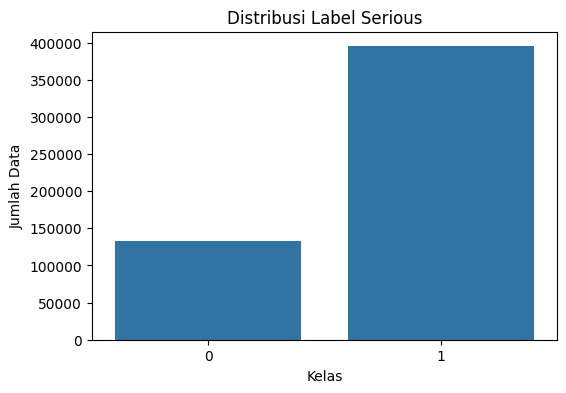

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='serious'
)

plt.title('Distribusi Label Serious')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')

plt.show()

##Imbalance ratio

In [ ]:
majority = df['serious'].value_counts().max()
minority = df['serious'].value_counts().min()

imbalance_ratio = majority / minority

print(f"Imbalance Ratio: {imbalance_ratio:.2f} : 1")

Imbalance Ratio: 2.97 : 1


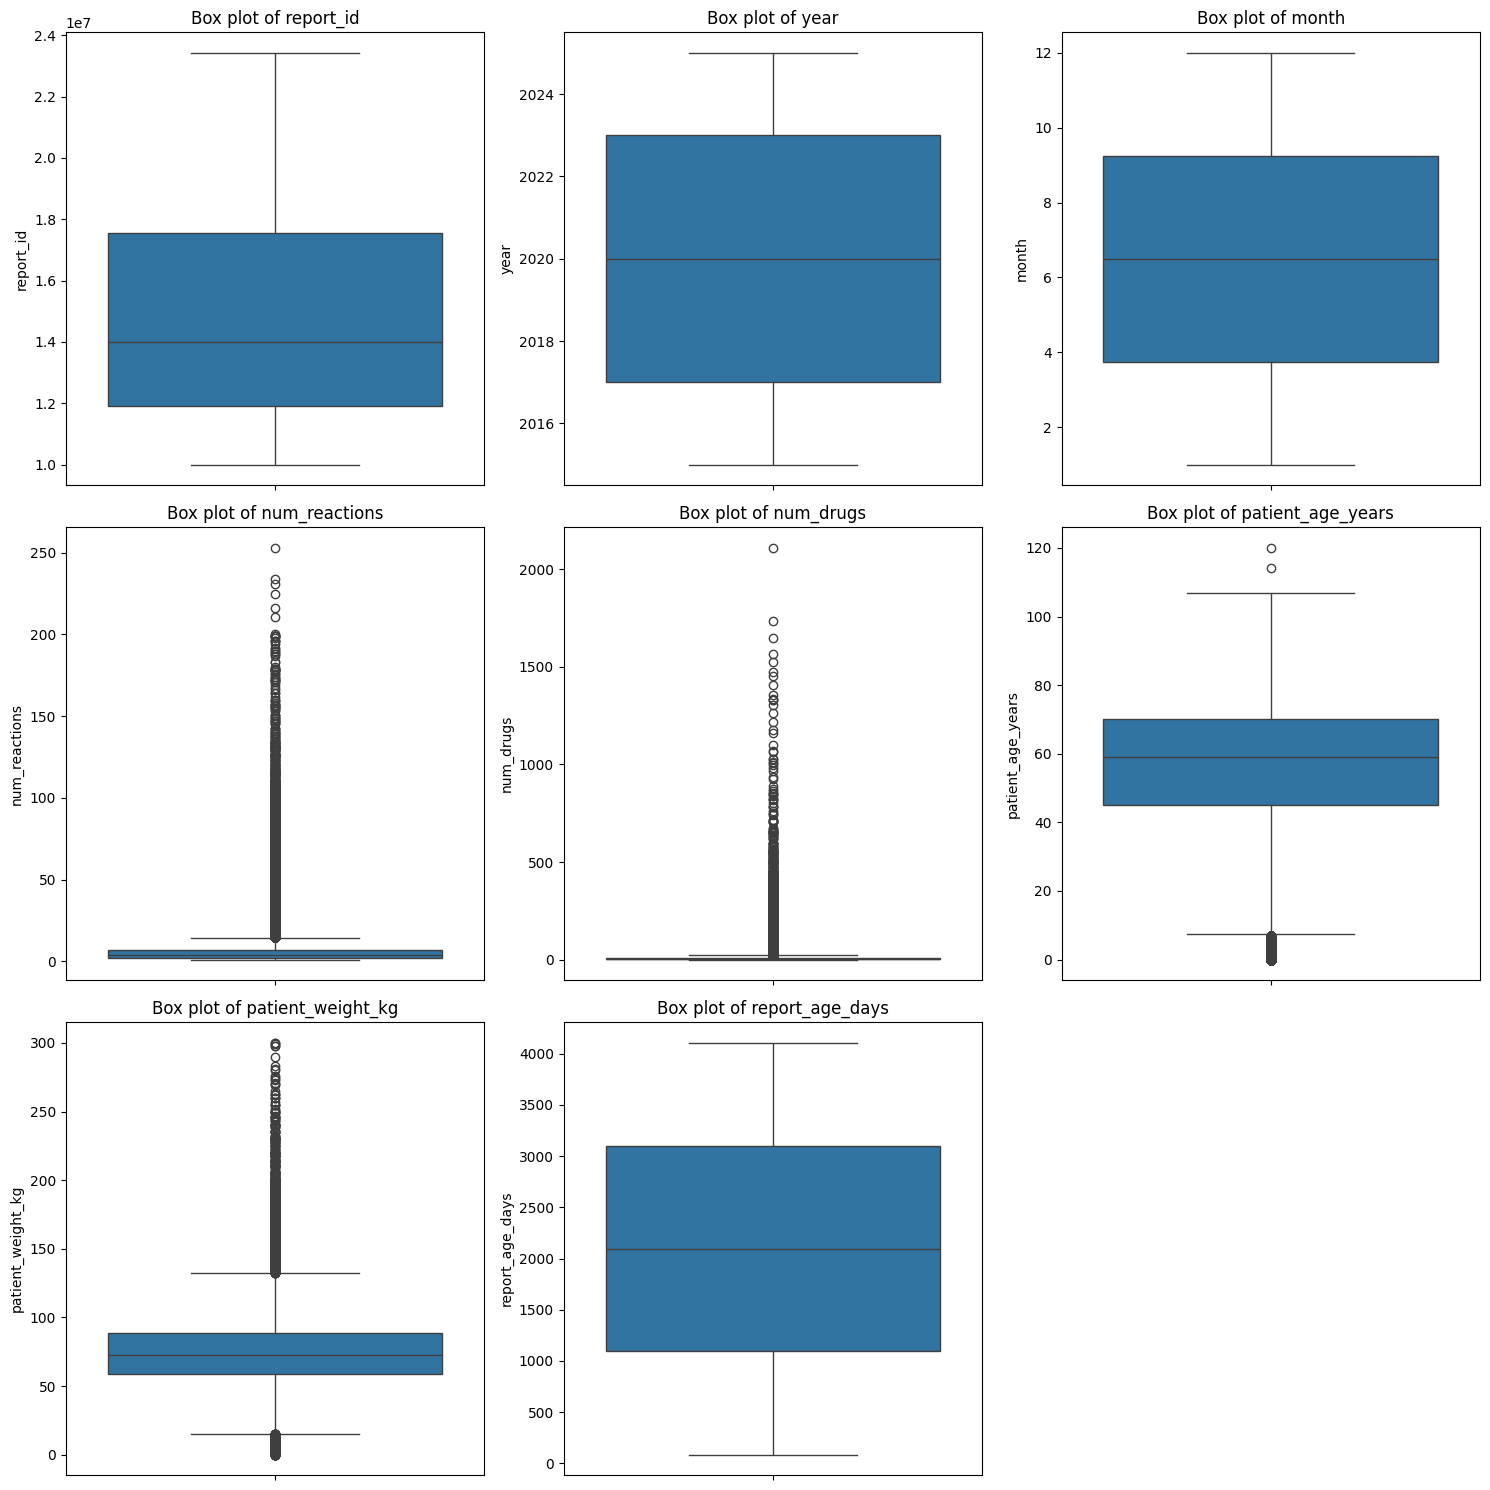

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_plots = len(numerical_cols)
num_rows = (num_plots + 2) // 3

plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  object 
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  object 
 5   serious              528000 non-null  object 
 6   serious_flags        226894 non-null  object 
 7   is_fatal             528000 non-null  bool   
 8   is_hospitalized      528000 non-null  bool   
 9   is_life_threat       528000 non-null  bool   
 10  is_disabling         528000 non-null  bool   
 11  reactions            528000 non-null  object 
 12  primary_reaction     528000 non-null  object 
 13  reaction_outcomes    528000 non-null  object 
 14  patient_recovered    528000 non-null  bool   
 15  num_reactions    

In [ ]:
df.shape

(528000, 30)

In [ ]:
df.describe()

,report_id,year,month,num_reactions,num_drugs,patient_age_years,patient_weight_kg,report_age_days
count,5.280000e+05,528000.000000,528000.000000,528000.000000,528000.000000,376491.000000,148077.000000,528000.000000
mean,1.478401e+07,2020.000000,6.500000,6.280659,8.698930,55.942629,74.343911,2096.257782
std,3.410052e+06,3.162281,3.452056,8.447020,19.416267,19.567057,26.273915,1160.025989
min,1.000331e+07,2015.000000,1.000000,1.000000,1.000000,0.000000,0.050000,87.000000
25%,1.191688e+07,2017.000000,3.750000,2.000000,2.000000,45.000000,59.000000,1092.750000
50%,1.398704e+07,2020.000000,6.500000,4.000000,4.000000,59.000000,72.560000,2096.500000
75%,1.754476e+07,2023.000000,9.250000,7.000000,10.000000,70.000000,88.435000,3100.250000
max,2.342467e+07,2025.000000,12.000000,253.000000,2108.000000,120.000000,300.000000,4104.000000


## Sparse / Missing value

In [ ]:
df.isnull().sum()

,0
report_id,0
receive_date,0
year,0
month,0
quarter,0
serious,0
serious_flags,301106
is_fatal,0
is_hospitalized,0
is_life_threat,0


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()


,0
report_id,0
receive_date,0
year,0
month,0
quarter,0
serious,0
serious_flags,0
is_fatal,0
is_hospitalized,0
is_life_threat,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Pre-processing

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
target = 'serious'

X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Shape X_train :", X_train_scaled.shape)
print("Shape X_test  :", X_test_scaled.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)

Shape X_train : (422400, 29)
Shape X_test  : (105600, 29)
Shape y_train : (422400,)
Shape y_test  : (105600,)


##Imbalanced Data

In [ ]:
df[target].value_counts()

,count
serious,
1,395000
0,133000


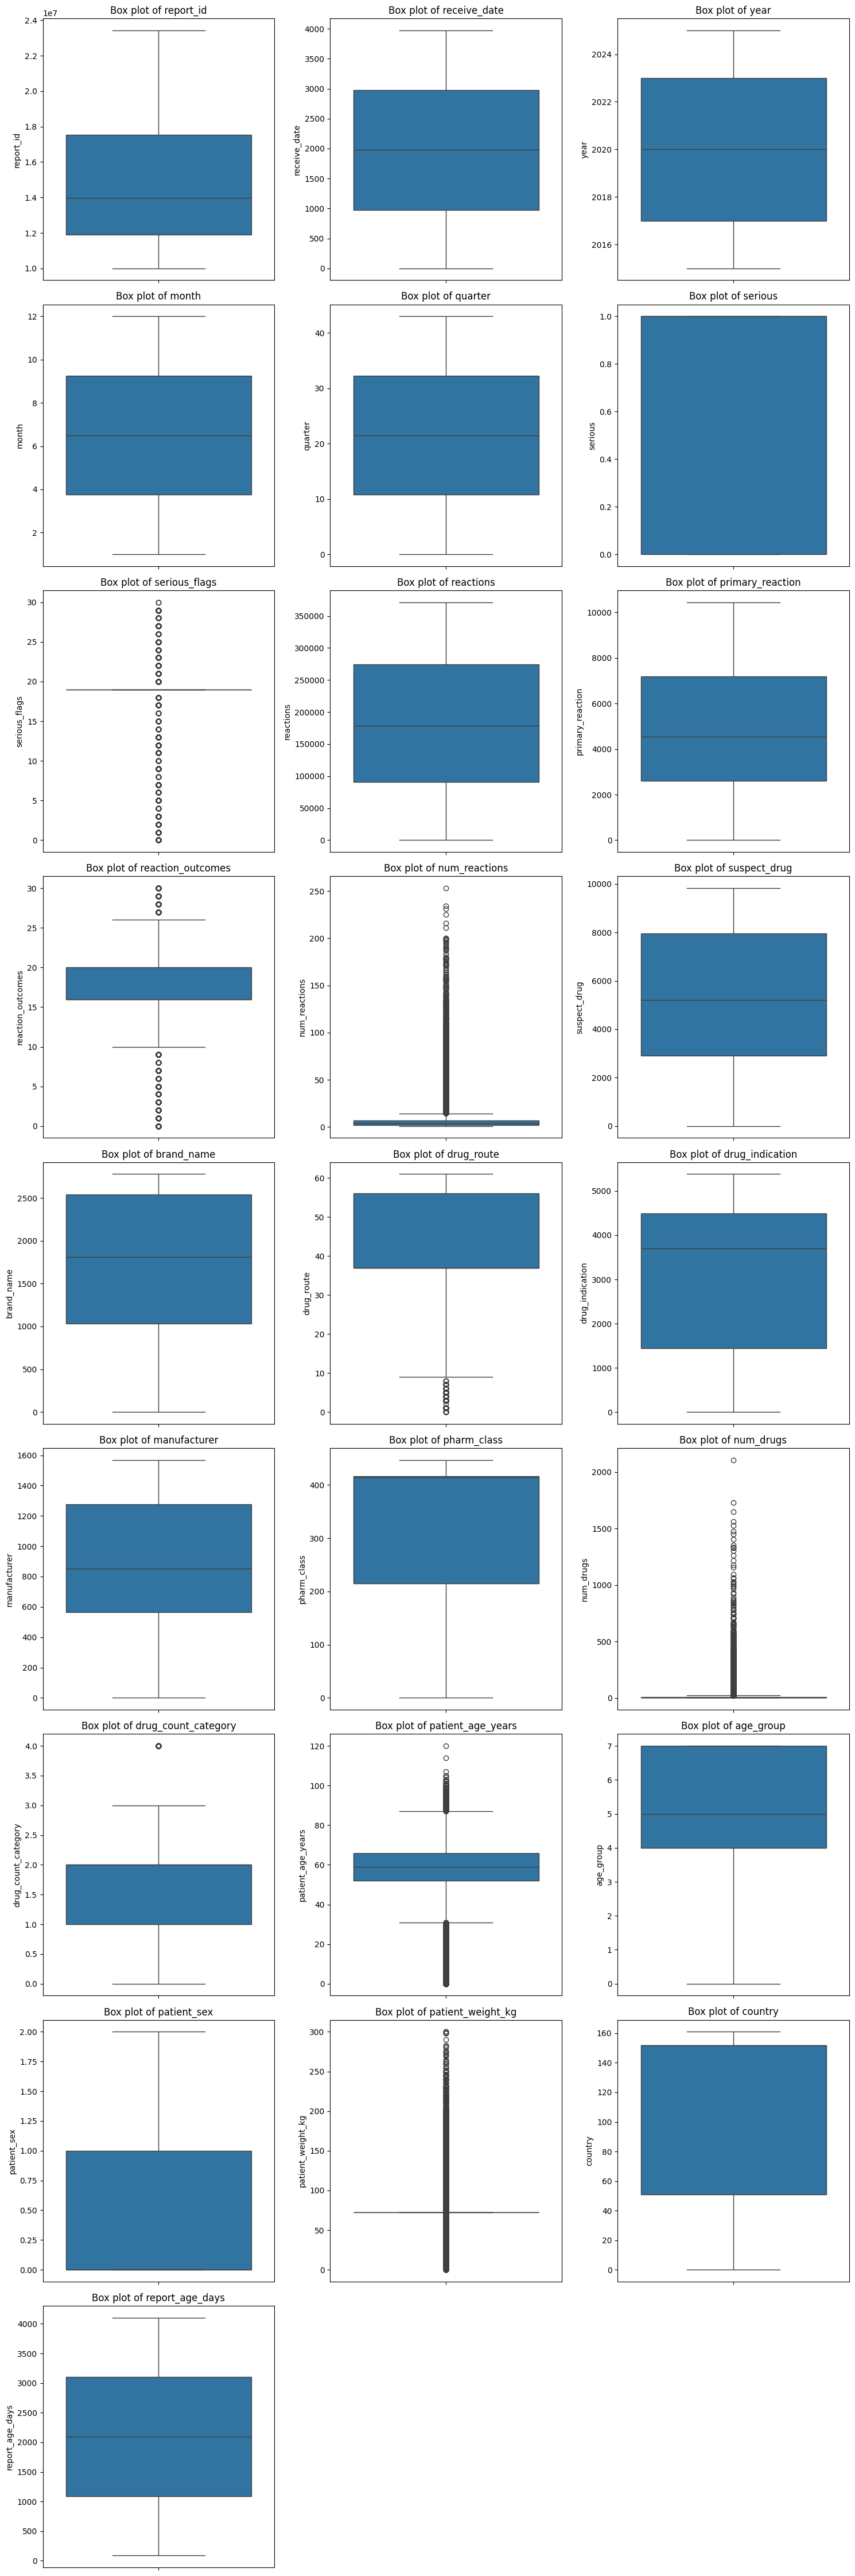

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_plots = len(numerical_cols)
num_rows = (num_plots + 2) // 3

plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()